In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

df = pd.read_csv('../data/processed/processed_data.csv')
df.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,churn
0,0,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,0
1,1,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,0
2,1,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,1
3,1,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,0
4,0,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,1


<Axes: xlabel='churn', ylabel='count'>

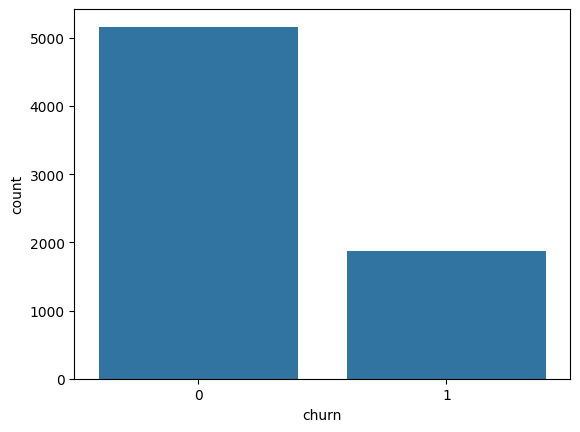

In [2]:
df['churn'].value_counts()
df['churn'].value_counts(normalize=True)
sns.countplot(x='churn', data=df)

<Axes: xlabel='churn', ylabel='tenure'>

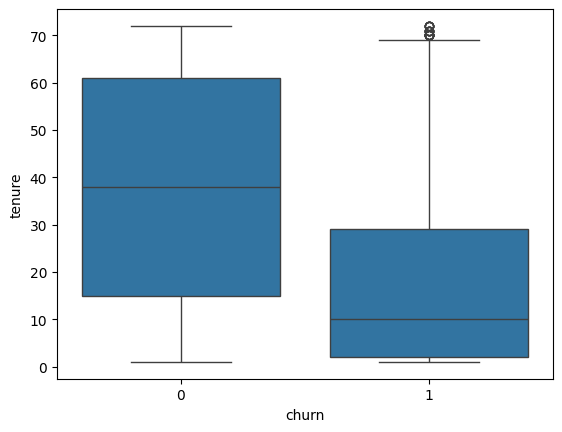

In [3]:
sns.boxplot(data = df, x='churn', y='tenure')


<Axes: xlabel='churn', ylabel='monthlycharges'>

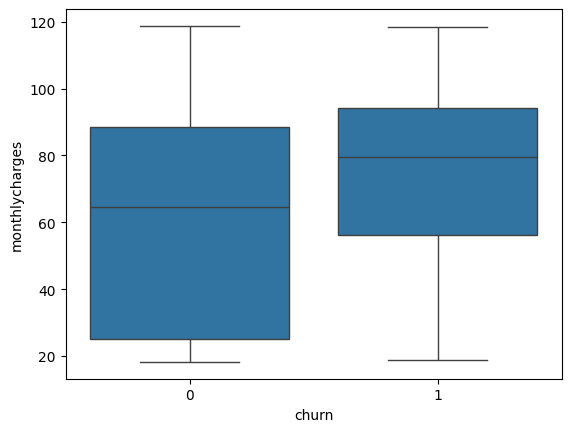

In [4]:
sns.boxplot(x='churn', y='monthlycharges', data=df)

contract
Month-to-month    0.427097
One year          0.112772
Two year          0.028487
Name: churn, dtype: float64


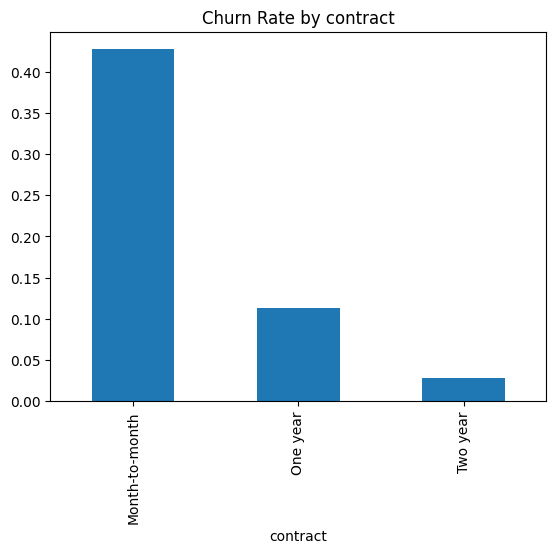

internetservice
Fiber optic    0.418928
DSL            0.189983
No             0.074342
Name: churn, dtype: float64


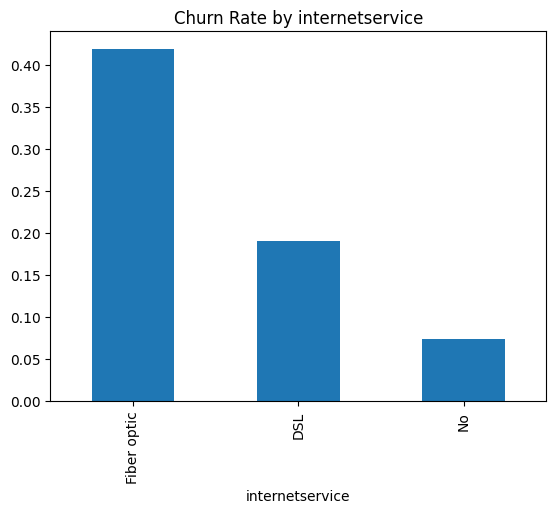

paymentmethod
Electronic check             0.452854
Mailed check                 0.192020
Bank transfer (automatic)    0.167315
Credit card (automatic)      0.152531
Name: churn, dtype: float64


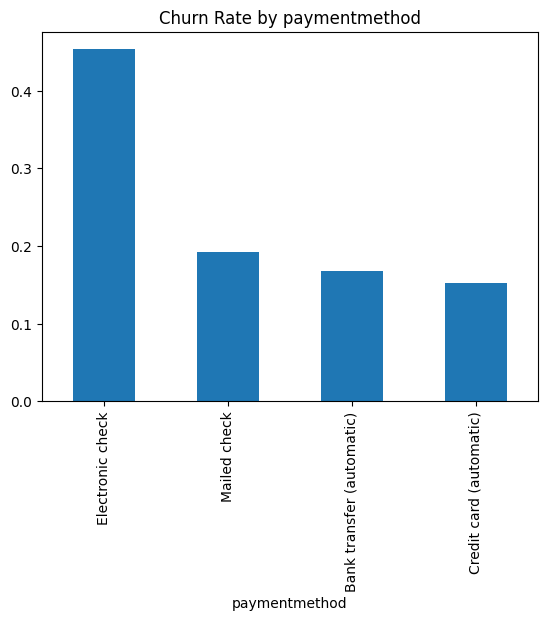

In [5]:
for col in ['contract', 'internetservice', 'paymentmethod']:
    print(df.groupby(col)['churn'].mean().sort_values(ascending=False))
    df.groupby(col)['churn'].mean().sort_values(ascending=False).plot(kind='bar')
    plt.title(f'Churn Rate by {col}')
    plt.show()

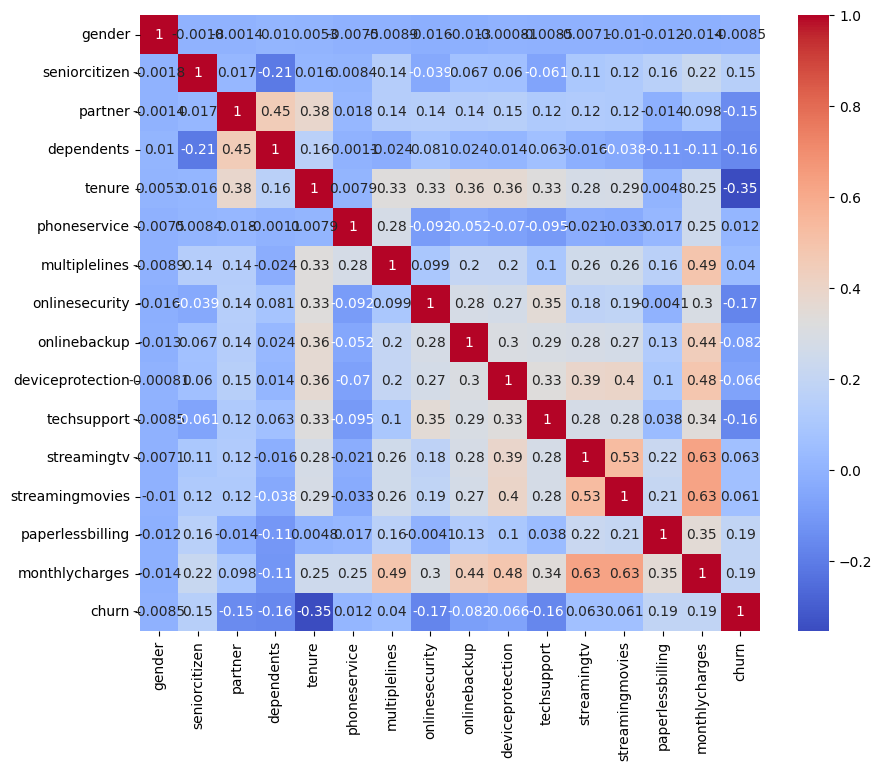

In [6]:
corr = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [7]:
for col in ['contract', 'internetservice', 'paymentmethod']:
    print(f'\n{col.upper()}')
    print(df.groupby(col)['churn'].mean().sort_values(ascending=False))


CONTRACT
contract
Month-to-month    0.427097
One year          0.112772
Two year          0.028487
Name: churn, dtype: float64

INTERNETSERVICE
internetservice
Fiber optic    0.418928
DSL            0.189983
No             0.074342
Name: churn, dtype: float64

PAYMENTMETHOD
paymentmethod
Electronic check             0.452854
Mailed check                 0.192020
Bank transfer (automatic)    0.167315
Credit card (automatic)      0.152531
Name: churn, dtype: float64


To test the hypotheses regarding the impact of categorical variables on churn, a group analysis was conducted, calculating the mean value of the target variable. This made it possible to estimate the probability of churn for each category.

In [8]:
df['is_month_to_month'] = (df['contract'] == 'Month-to-month').astype(int)

df['high_risk'] = (
    df['contract'] == 'Month-to-month') & (df['internetservice'] == 'Fiber optic') & (df['paymentmethod'] == 'Electronic check'
).astype(int)

In [9]:
df = pd.get_dummies(df, columns=['contract', 'internetservice', 'paymentmethod'], drop_first=True)

In [10]:
df.info()
df.describe()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   seniorcitizen                          7032 non-null   int64  
 2   partner                                7032 non-null   int64  
 3   dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   phoneservice                           7032 non-null   int64  
 6   multiplelines                          7032 non-null   int64  
 7   onlinesecurity                         7032 non-null   int64  
 8   onlinebackup                           7032 non-null   int64  
 9   deviceprotection                       7032 non-null   int64  
 10  techsupport                            7032 non-null   int64  
 11  streamingtv    

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,paperlessbilling,monthlycharges,churn,is_month_to_month,high_risk,contract_One year,contract_Two year,internetservice_Fiber optic,internetservice_No,paymentmethod_Credit card (automatic),paymentmethod_Electronic check,paymentmethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,29.85,0,1,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,0,0,0,0,56.95,0,0,False,True,False,False,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,0,0,0,1,53.85,1,1,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,1,0,0,0,42.30,0,0,False,True,False,False,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,0,0,0,1,70.70,1,1,True,False,False,True,False,False,True,False


In [11]:
df.to_csv('../data/processed/finished_data.csv', index=False)